In [1]:
import pandas as pd

df = pd.read_csv('/kaggle/input/storm-data/storm_daily_stats.csv')
df.describe()

,day,per_day_distance,avg_speed,motion_type,total_distance_of_storm,total_lifetime
count,26152.000000,26152.000000,26152.000000,26152.000000,26152.000000,26152.000000
mean,4.807128,421.560411,17.565017,2.295274,3758.079558,8.614255
std,3.597546,250.687038,10.445293,0.576585,2524.224275,4.530450
min,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000
25%,2.000000,255.011924,10.625497,2.000000,1708.326796,5.000000
50%,4.000000,376.321439,15.680060,2.000000,3211.057820,8.000000
75%,7.000000,529.821422,22.075893,3.000000,5252.502850,11.000000
max,28.000000,2698.523104,112.438463,5.000000,13427.254891,28.000000


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26152 entries, 0 to 26151
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   sid                      26152 non-null  object 
 1   day                      26152 non-null  int64  
 2   per_day_distance         26152 non-null  float64
 3   avg_speed                26152 non-null  float64
 4   motion_type              26152 non-null  int64  
 5   total_distance_of_storm  26152 non-null  float64
 6   total_lifetime           26152 non-null  int64  
dtypes: float64(3), int64(3), object(1)
memory usage: 1.4+ MB


In [ ]:
import random
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence
from torch.optim.lr_scheduler import ReduceLROnPlateau


torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# ---------------------- LOAD DATA ----------------------
df = pd.read_csv('/kaggle/input/storm-data/storm_daily_stats.csv')

unique_sids = np.array(sorted(df['sid'].unique()))
np.random.shuffle(unique_sids)

n = len(unique_sids)
n_train = int(0.8 * n)
n_val = int(0.05 * n)
train_sids = unique_sids[:n_train]
val_sids = unique_sids[n_train:n_train + n_val]
test_sids = unique_sids[n_train + n_val:]

print(f"Total: {n}, Train: {len(train_sids)}, Val: {len(val_sids)}, Test: {len(test_sids)}")

# ---------------------- BUILD PARTIAL SEQUENCES ----------------------
def build_partial_sequences(df, sids):
    samples = []
    for sid in sids:
        g = df[df["sid"] == sid].sort_values("day")
        full_target = float(g["total_distance_of_storm"].iloc[0])
        feats = g[INPUT_FEATURES].values.astype(np.float32)
        T = len(feats)
        for k in range(1, T + 1):
            seq = torch.tensor(feats[:k], dtype=torch.float32)
            tgt = torch.tensor([full_target], dtype=torch.float32)
            samples.append((seq, tgt))
    return samples

train_seq = build_partial_sequences(df, train_sids)
val_seq   = build_partial_sequences(df, val_sids)
test_seq  = build_partial_sequences(df, test_sids)

# ---------------------- DATASET ----------------------
class StormDataset(Dataset):
    def __init__(self, seqs):
        self.seqs = seqs
    def __len__(self):
        return len(self.seqs)
    def __getitem__(self, i):
        return self.seqs[i]

def collate_fn(batch):
    seqs = [b[0] for b in batch]
    tgts = torch.stack([b[1].squeeze(0) for b in batch])
    lengths = torch.tensor([len(s) for s in seqs])
    padded = pad_sequence(seqs, batch_first=True)
    return padded, lengths, tgts

train_loader = DataLoader(StormDataset(train_seq), batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader   = DataLoader(StormDataset(val_seq), batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(StormDataset(test_seq), batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)


In [32]:
SEED = 42
BATCH_SIZE = 64
EPOCHS = 1000
LR = 1e-3
PATIENCE = 50
HIDDEN_SIZE = 256
NUM_LAYERS = 2
DROPOUT = 0.2
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
INPUT_FEATURES = ["day", "per_day_distance", "avg_speed", "motion_type"]
TARGET = "total_distance_of_storm"

# ---------------------- MODEL ----------------------
class StormLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=False,  
            bidirectional=False
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Linear(hidden_size // 2, 1)
        )

    def forward(self, x, lengths):
        # x: (B, L, F)
        packed = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (h_n, _) = self.lstm(packed)
        out = self.fc(h_n[-1]) 
        return out.squeeze(-1)

# ---------------------- METRICS ----------------------
def rmse(pred, true): return torch.sqrt(torch.mean((pred - true) ** 2)).item()
def mape(pred, true):
    mask = true != 0
    return (torch.mean((torch.abs((pred[mask] - true[mask]) / true[mask])))*100).item()
def r2(pred, true):
    ss_res = torch.sum((true - pred) ** 2)
    ss_tot = torch.sum((true - true.mean()) ** 2)
    return (1 - ss_res / ss_tot).item()

# ---------------------- TRAINING SETUP ----------------------
model = StormLSTM(len(INPUT_FEATURES), HIDDEN_SIZE, NUM_LAYERS, DROPOUT).to(DEVICE)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10, verbose=True)

best_val = float('inf')
wait = 0

history = {"train_loss": [], "val_loss": [], "rmse": [], "mape": [], "r2": []}

# ---------------------- TRAIN LOOP ----------------------
for epoch in range(1, EPOCHS+1):
    model.train()
    train_loss = 0
    for x, lengths, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        pred = model(x, lengths)
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(y)
    train_loss /= len(train_loader.dataset)

    # ---- validation ----
    model.eval()
    val_loss, preds, tgts = 0, [], []
    with torch.no_grad():
        for x, lengths, y in val_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            p = model(x, lengths)
            loss = criterion(p, y)
            val_loss += loss.item() * len(y)
            preds.append(p.cpu())
            tgts.append(y.cpu())
    val_loss /= len(val_loader.dataset)

    preds = torch.cat(preds)
    tgts = torch.cat(tgts)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["rmse"].append(rmse(preds, tgts))
    history["mape"].append(mape(preds, tgts))
    history["r2"].append(r2(preds, tgts))

    print(f"Epoch {epoch:03d} | Train {train_loss:.6f} | Val {val_loss:.6f} | RMSE {history['rmse'][-1]:.3f} | MAPE {history['mape'][-1]:.2f}% | R² {history['r2'][-1]:.3f}")

    scheduler.step(val_loss)
    if val_loss + 1e-6 < best_val:
        best_val = val_loss
        wait = 0
        best_state = model.state_dict()
    else:
        wait += 1
        if wait >= PATIENCE:
            print("Early stopping triggered.")
            break

# ---------------------- TEST ----------------------
model.load_state_dict(best_state)
model.eval()
preds, tgts = [], []
with torch.no_grad():
    for x, lengths, y in test_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        p = model(x, lengths)
        preds.append(p.cpu())
        tgts.append(y.cpu())

preds = torch.cat(preds)
tgts = torch.cat(tgts)
test_rmse = rmse(preds, tgts)
test_mape = mape(preds, tgts)
test_r2 = r2(preds, tgts)

print(f"\nTest RMSE={test_rmse:.4f} | MAPE={test_mape:.2f}% | R²={test_r2:.4f}")

torch.save({
    'model_state_dict': model.state_dict(),
    'history': history,
}, "/kaggle/working/lstm_regressor.pt")

print("Saved model to /kaggle/working/lstm_predict.pt")

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 001 | Train 14073285.427082 | Val 6907354.698842 | RMSE 2628.185 | MAPE 76.57% | R² -0.040
Epoch 002 | Train 5002637.314962 | Val 4200511.332898 | RMSE 2049.515 | MAPE 65.06% | R² 0.368
Epoch 003 | Train 3914322.605435 | Val 4412951.637976 | RMSE 2100.703 | MAPE 77.30% | R² 0.336
Epoch 004 | Train 3723216.038272 | Val 3706112.699403 | RMSE 1925.127 | MAPE 67.68% | R² 0.442
Epoch 005 | Train 3658905.984209 | Val 3650012.894604 | RMSE 1910.501 | MAPE 58.60% | R² 0.451
Epoch 006 | Train 3623005.612504 | Val 3624618.708738 | RMSE 1903.843 | MAPE 61.28% | R² 0.454
Epoch 007 | Train 3605270.467124 | Val 3485395.596154 | RMSE 1866.921 | MAPE 56.70% | R² 0.475
Epoch 008 | Train 3608286.619429 | Val 3526368.101848 | RMSE 1877.863 | MAPE 56.56% | R² 0.469
Epoch 009 | Train 3569158.028701 | Val 3523643.692121 | RMSE 1877.137 | MAPE 61.61% | R² 0.470
Epoch 010 | Train 3566352.829052 | Val 3462364.574122 | RMSE 1860.743 | MAPE 62.75% | R² 0.479
Epoch 011 | Train 3570772.165826 | Val 3561213.0

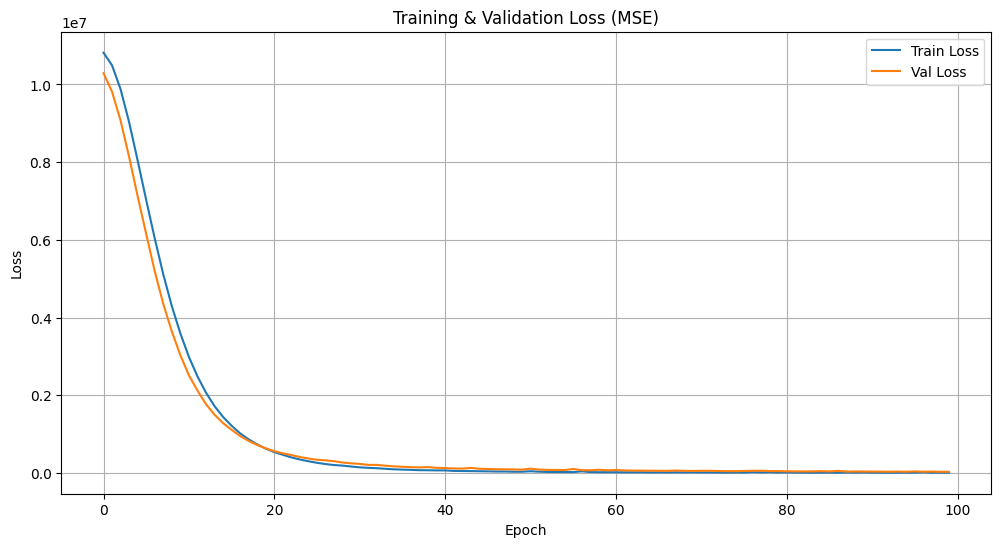

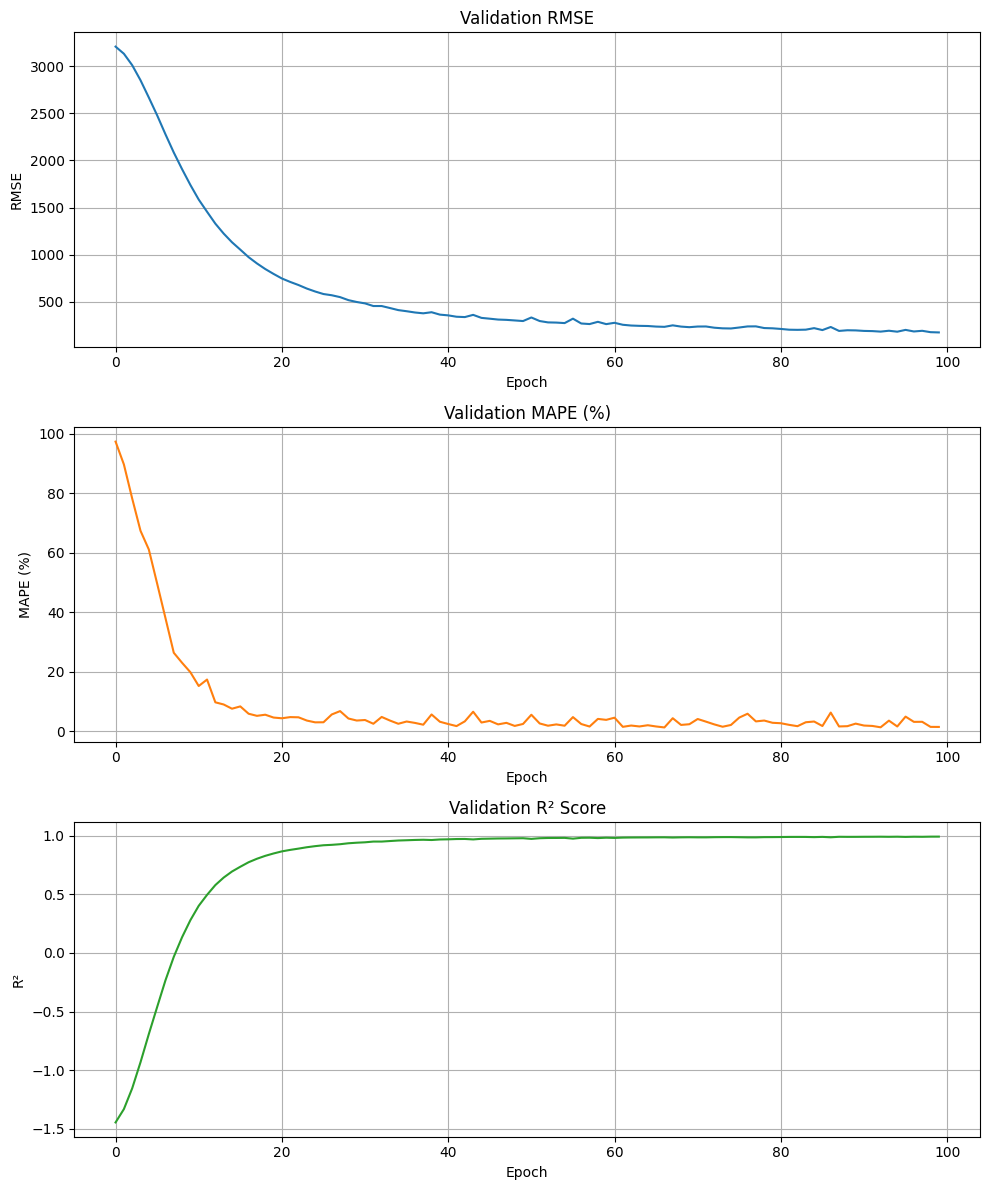

In [4]:
import matplotlib.pyplot as plt

# --- 1. Train vs Validation Loss ---
plt.figure(figsize=(12, 6))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.title("Training & Validation Loss (MSE)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# --- 2. RMSE, MAPE, and R² curves ---
fig, axs = plt.subplots(3, 1, figsize=(10, 12))

axs[0].plot(history["rmse"], label="Val RMSE", color='tab:blue')
axs[0].set_title("Validation RMSE")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("RMSE")
axs[0].grid(True)

axs[1].plot(history["mape"], label="Val MAPE", color='tab:orange')
axs[1].set_title("Validation MAPE (%)")
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("MAPE (%)")
axs[1].grid(True)

axs[2].plot(history["r2"], label="Val R²", color='tab:green')
axs[2].set_title("Validation R² Score")
axs[2].set_xlabel("Epoch")
axs[2].set_ylabel("R²")
axs[2].grid(True)

plt.tight_layout()
plt.show()
